In [96]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import sympy as sp

In [97]:

# ============================
# Parameters
# ============================

SECONDS_PER_YEAR = 365 * 24 * 3600
### anthropogenic emissions ###
A_tot = 5000.0   # GtC, total carbon emitted
t_opt = 150.0    # yr, t_opt for RCP8.5

t = sp.symbols("t", real=True)

# Cumulative emissions A(t)
A = A_tot * (
    1 / (1 + 2.5 * sp.exp((t_opt - t) / 50))
    - 1 / (1 + 2.5 * sp.exp(t_opt / 50))
)

# Emission rate J(t) = dA/dt
J = sp.diff(A, t)
# define instantaneous emission rate function J(t) as a function of time t

# Fast numerical functions
A_func = sp.lambdify(t, A, "numpy")
J_func = sp.lambdify(t, J, "numpy")

### inital Temperature ###
Ts_init = 0.0      # K, initial surface temperature
Td_init = 0.0      # K, initial deep ocean temperature
lam_star = 0.75       # W m^-2 K^-1, heat transfer coefficient
lam = 1.75         # W m^-2 K^-1, climate feedback parameter
beta = 5.35        # W m^-2 K^-1, CO2 forcing parameter


### Heat capacities ###
surface_depth = 50.0
deep_depth = 3000.0
c_s = 4000.0 * surface_depth * 1000.0      # J m^-2 K^-1
c_d = 4000.0 * deep_depth * 1000.0       # J m^-2 K^-1
c_star = c_s + c_d                     # J m^-2 K^-1

### atmospheric carbon ###
k_a  = 2.12          # CO2 scaling constant
Ca_init = 600.0         # GtC, pre-industrial atmospheric carbon
P_a0 = Ca_init / k_a    # ppm, pre-industrial atmospheric CO2

etaH = 0.7         # W m^-2 K^-1, heat transfer coefficient

### land carbon ###
beta_pi = 0.4     # CO2 fertilization factor
chi     = 1.8     # scaling constant
tau_l0   = 41.0    # yr, lifetime of land carbon
Pi_0    = 60.0    # GtC/yr, preindustrial land flux
Cl_init    = 2460.0  # GtC, preindustrial land carbon

### ocean carbon cycle ###
D     = surface_depth + deep_depth     # m, average ocean depth
delta = surface_depth / D    # fraction (mixed-layer depth / D)
gamma = 0.02        # GtC/yr/ppm, air-sea transfer coefficient
mu_0  = 5.0        # buffer constant (m/year)
zeta  = 6#10.5        # ratio between ocean reservoirs and atmosphere
etaC = mu_0/D       # transfer rate by total depth

# C_s0 + C_d0 = 6 * zeta * C_a0
# C_s0 / C_d0 = delta / (1 - delta)
# => solve the two simultaneous equations for C_s0, C_d0

total_sd = 6.0 * zeta * Ca_init   # GtC, total preindustrial ocean carbon
Cd_init = (1-delta) * total_sd   # GtC, preindustrial deep ocean carbon

Cs_init = total_sd - Cd_init               # GtC, preindustrial surface ocean carbon

kappa_o = 6.0 * k_a * delta   # ocean CO2 uptake constant


def box_rhs(t, y, scenario=1):
    """
    scenario=1: anthropogenic emissions J enter the atmosphere (dCa)
    scenario=2: anthropogenic emissions J enter the deep ocean (dCd)
    """
    Ts, Td, Cs, Cd, Ca, Cl = y

    ### Anthropogenic emissions ###

    J = J_func(t)  # GtC/seconds

    ### Temperature evolution surface and deep ###

    forcing = beta * np.log(Ca / Ca_init + 1.0)

    dTs = (
        (-lam*Ts
        + forcing
        - (etaH + lam_star)*(Ts - Td))
        * SECONDS_PER_YEAR
        / (delta * c_star)
    )

    dTd = (
        etaH*(Ts - Td)
        * SECONDS_PER_YEAR
        / ((1-delta)*c_star)
    )

    ### Land carbon evolution ###

    dCl = (
        Pi_0 * (1 + beta_pi * np.log((Ca / Ca_init) + 1.0))
        - ((Cl+Cl_init) / tau_l0) * chi ** (Ts / 10.0)
    )

    ### Surface ocean carbon evolution ###

    ko = k_a / zeta * (Cs_init / Ca_init)

    dCs = gamma * (Ca / k_a - Cs / ko) - etaC * (Cs/delta - Cd/(1-delta))

    ### Deep ocean carbon evolution ###

    dCd = etaC * (Cs/delta - Cd/(1-delta))

    ### Atmosphere carbon evolution ###

    dCa = -dCs - dCl - dCd

    if scenario == 1:
        # J enters the atmosphere
        dCa = J - dCs - dCl - dCd
    elif scenario == 2:
        # J enters the deep ocean
        dCd = dCd + J
    elif scenario == 3:
        # J enters the surface ocean
        dCs = dCs + J
    elif scenario == 4:
        # J enters the land
        dCl = dCl + J

    return [dTs, dTd, dCs, dCd, dCa, dCl]


In [ ]:
y_box = [0, 0, 0, 0, 0, 0]
t = np.arange(0, 6000, 1) # time in seconds

forcing = 0
solver_kwargs = dict(method='RK45', t_eval=t, rtol=1e-8, atol=1e-10)

# Scenario 1: J enters the atmosphere (dCa)
y_box = [0, 0, 0, 0, forcing, 0]
sol_box_s1 = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=1),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)

# Scenario 2: J enters the deep ocean (dCd)
y_box = [0, 0, 0, forcing, 0, 0]
sol_box_s2 = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=2),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)

# Scenario 3: J enters the surface ocean (dCs)
y_box = [0, 0, forcing, 0, 0, 0]
sol_box_s3 = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=3),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)

# Scenario 4: J enters the land (dCl)
y_box = [0, 0, 0, 0, 0, forcing]
sol_box_s4 = spi.solve_ivp(
    lambda t, y: box_rhs(t, y, scenario=4),
    (t[0], t[-1]),
    y_box,
    **solver_kwargs
)


In [102]:

def find_equilibrium_time(t, gradient, tolerance = 1e-3):
    """
    Finds the first value from behind where the gradient is more than the tolerance
    and then returns the corresponding time. If no such value is found, returns None.
    """
    for i in range(len(gradient)-1, -1, -1):
        if abs(gradient[i]) > tolerance:
            return t[i]  # return time in years
    return None

# Compute gradients (dy/dt) by re-evaluating box_rhs at each stored time step.
# This gives exact ODE derivatives, shape (6, N), matching sol.y.
def compute_gradients(sol, scenario):
    grads = np.array([box_rhs(ti, yi, scenario=scenario)
                      for ti, yi in zip(sol.t, sol.y.T)])
    return grads.T  # shape: (n_vars, n_timepoints)

grad_s1 = compute_gradients(sol_box_s1, scenario=1)
grad_s2 = compute_gradients(sol_box_s2, scenario=2)
grad_s3 = compute_gradients(sol_box_s3, scenario=3)
grad_s4 = compute_gradients(sol_box_s4, scenario=4)

find_equilibrium_time(t, grad_s1[2], tolerance = 1e-3)


np.int64(1664)

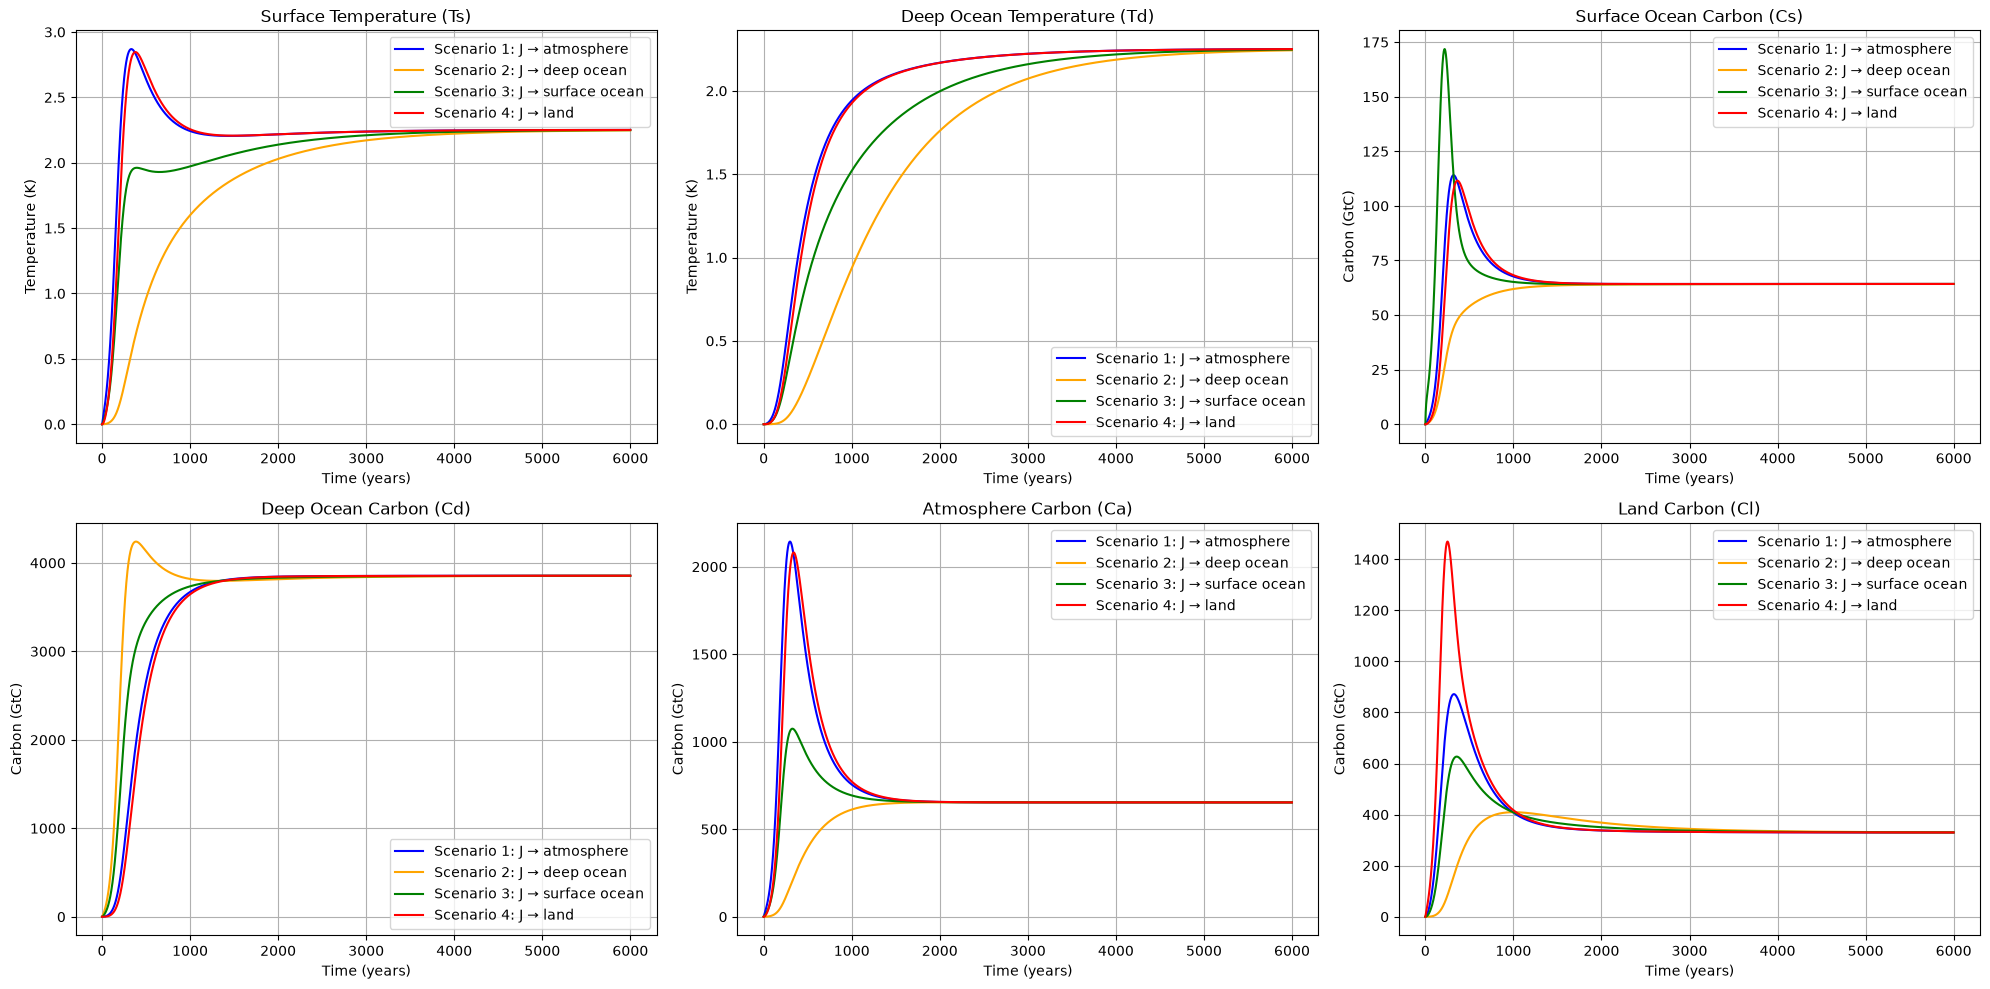

In [99]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
axs = axs.flatten()

titles = [
    'Surface Temperature (Ts)', 'Deep Ocean Temperature (Td)',
    'Surface Ocean Carbon (Cs)', 'Deep Ocean Carbon (Cd)',
    'Atmosphere Carbon (Ca)', 'Land Carbon (Cl)'
]
ylabels = ['Temperature (K)', 'Temperature (K)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)']

for sol, color, label in [
    (sol_box_s1, 'blue',  'Scenario 1: J → atmosphere'),
    (sol_box_s2, 'orange', 'Scenario 2: J → deep ocean'),
    (sol_box_s3, 'green', 'Scenario 3: J → surface ocean'),
    (sol_box_s4, 'red', 'Scenario 4: J → land')
]:
    for i in range(sol.y.shape[0]):
        axs[i].plot(sol.t, sol.y[i], label=label, color=color)

for i, ax in enumerate(axs):
    ax.set_xlabel('Time (years)')
    ax.set_ylabel(ylabels[i])
    ax.set_title(titles[i])
    ax.grid()
    ax.legend()

plt.tight_layout()


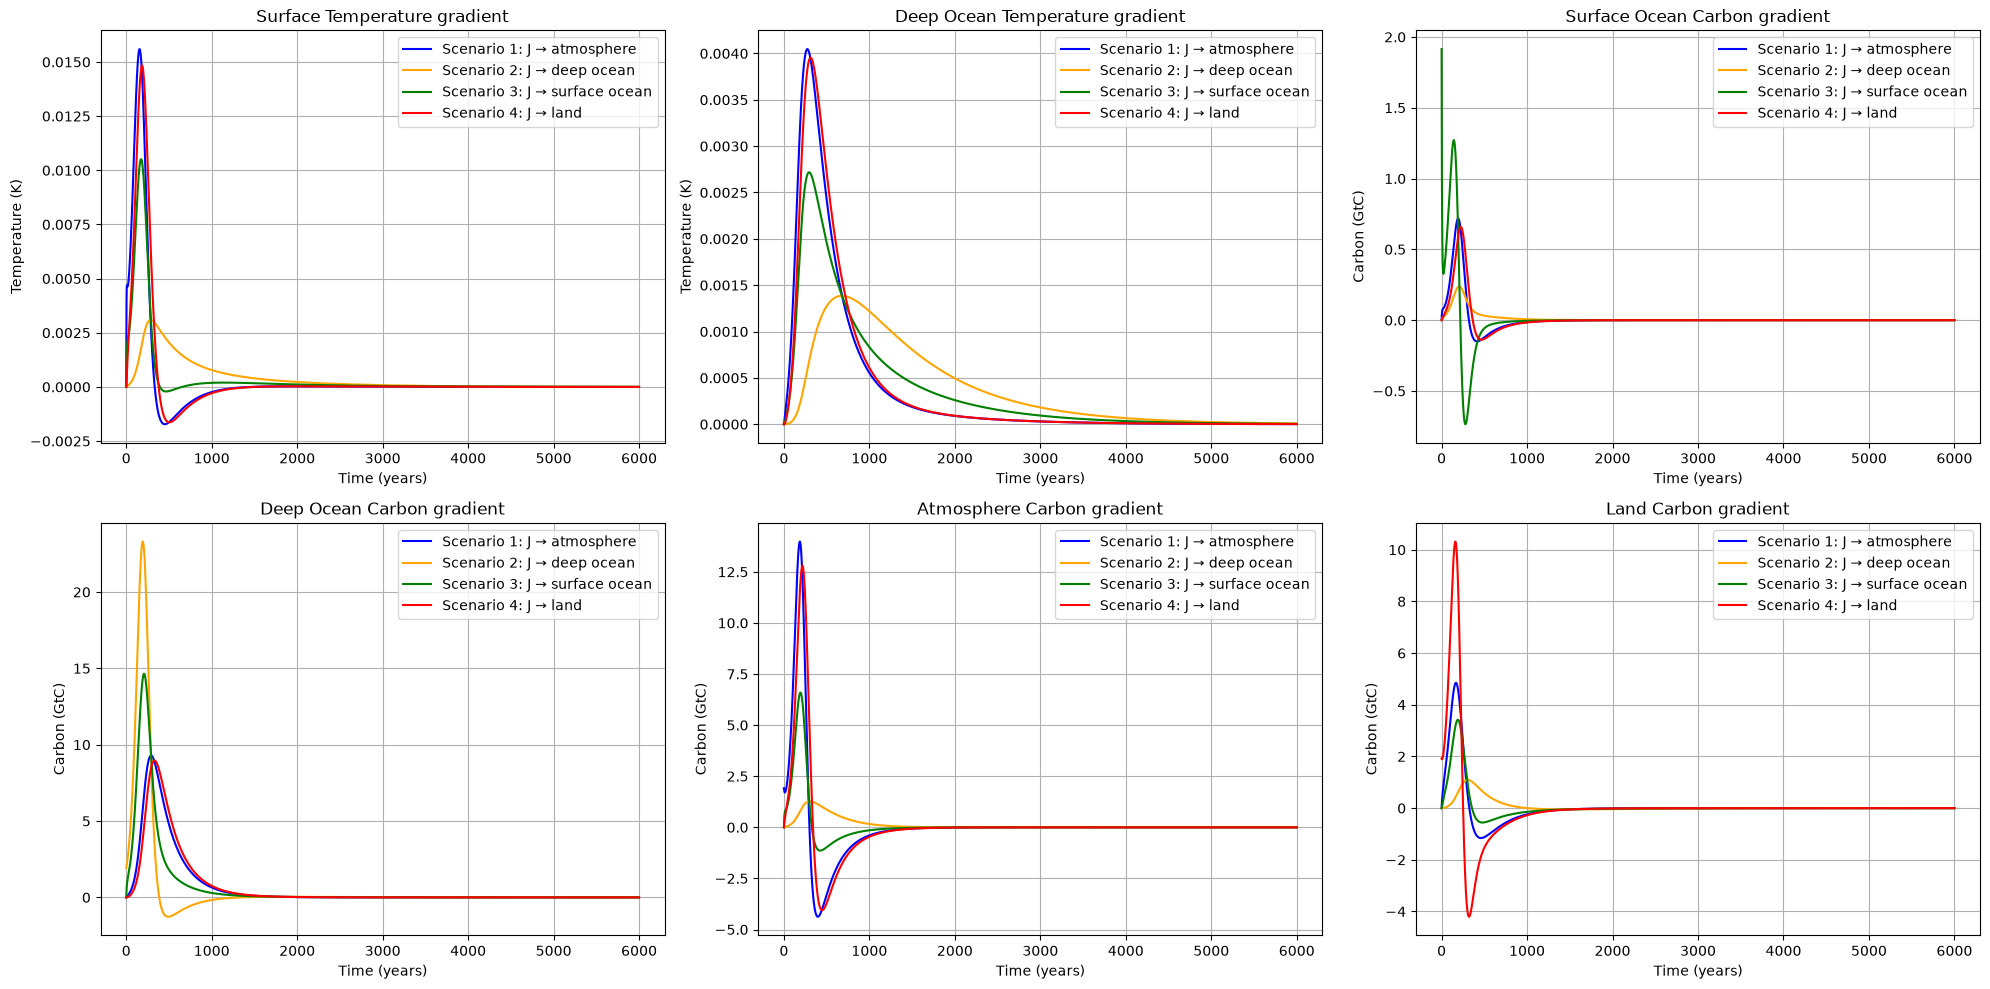

In [104]:
fig, axs = plt.subplots(2, 3, figsize=(20, 10))
axs = axs.flatten()

titles = [
    'Surface Temperature gradient', 'Deep Ocean Temperature gradient',
    'Surface Ocean Carbon gradient', 'Deep Ocean Carbon gradient',
    'Atmosphere Carbon gradient', 'Land Carbon gradient'
]
ylabels = ['Temperature (K)', 'Temperature (K)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)', 'Carbon (GtC)']

for sol, grad, color, label in [
    (sol_box_s1, grad_s1, 'blue',   'Scenario 1: J → atmosphere'),
    (sol_box_s2, grad_s2, 'orange', 'Scenario 2: J → deep ocean'),
    (sol_box_s3, grad_s3, 'green',  'Scenario 3: J → surface ocean'),
    (sol_box_s4, grad_s4, 'red',    'Scenario 4: J → land')
]:
    for i in range(grad.shape[0]):
        axs[i].plot(sol.t, grad[i], label=label, color=color)
for i, ax in enumerate(axs):
    ax.set_xlabel('Time (years)')
    ax.set_ylabel(ylabels[i])
    ax.set_title(titles[i])
    ax.grid()
    ax.legend()

plt.tight_layout()
